# 01 — Data EDA: Patent Vectorization Pipeline

**Purpose**: Answer 8 data quality questions before writing any pipeline code.  
**Data**: Three parquet files prepared by Amie Le Hoang (2020 patent window).  
**Memory-safety**: Column-selective reads, sampling, streaming batches — never load full datasets into RAM.

In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data")
patent_path = DATA_DIR / "patent_metadata.parquet"
cited_path = DATA_DIR / "cited_abstracts.parquet"
citation_path = DATA_DIR / "citation_network.parquet"

# Verify files exist
for p in [patent_path, cited_path, citation_path]:
    assert p.exists(), f"Missing: {p}"
    meta = pq.read_metadata(p)
    print(f"{p.name}: {meta.num_rows:,} rows, {meta.num_columns} cols")

patent_metadata.parquet: 1,211,889 rows, 8 cols
cited_abstracts.parquet: 1,872,555 rows, 3 cols
citation_network.parquet: 16,698,056 rows, 3 cols


## Q1: Schema Verification

Do columns match expectations from `data_prep.md`?  
Expected: patent_metadata (gvkey, patent_id, title, abstract), cited_abstracts (patent_id, abstract), citation_network (patent_id, citation_id).

In [2]:
# Read schemas without loading data
for name, path in [("patent_metadata", patent_path), ("cited_abstracts", cited_path), ("citation_network", citation_path)]:
    schema = pq.read_schema(path)
    print(f"\n{name}:")
    for i, field in enumerate(schema):
        print(f"  {field.name}: {field.type}")


patent_metadata:
  gvkey: string
  permno: int64
  patent_id: string
  year: int32
  grant_date: string
  title: string
  abstract: string
  __index_level_0__: int64

cited_abstracts:
  patent_id: string
  abstract: string
  __index_level_0__: int64

citation_network:
  patent_id: string
  citation_id: string
  __index_level_0__: int64


## Q2: Null Rates

What percentage of patents have null/empty title or abstract? These would be unusable for embedding.

In [3]:
# Load only text columns to check nulls
pm = pq.read_table(patent_path, columns=["patent_id", "title", "abstract"]).to_pandas()
total = len(pm)

null_title = pm["title"].isna().sum()
null_abstract = pm["abstract"].isna().sum()
empty_title = (pm["title"].fillna("").str.strip() == "").sum()
empty_abstract = (pm["abstract"].fillna("").str.strip() == "").sum()
both_missing = ((pm["title"].isna() | (pm["title"].str.strip() == "")) & 
               (pm["abstract"].isna() | (pm["abstract"].str.strip() == ""))).sum()

print(f"Total patents: {total:,}")
print(f"Null title:    {null_title:,} ({null_title/total:.2%})")
print(f"Empty title:   {empty_title:,} ({empty_title/total:.2%})")
print(f"Null abstract: {null_abstract:,} ({null_abstract/total:.2%})")
print(f"Empty abstract:{empty_abstract:,} ({empty_abstract/total:.2%})")
print(f"Both missing:  {both_missing:,} ({both_missing/total:.2%})")
print(f"\nUsable patents (have at least title or abstract): {total - both_missing:,}")

Total patents: 1,211,889
Null title:    0 (0.00%)
Empty title:   0 (0.00%)
Null abstract: 241 (0.02%)
Empty abstract:241 (0.02%)
Both missing:  0 (0.00%)

Usable patents (have at least title or abstract): 1,211,889


In [4]:
# Also check cited_abstracts for nulls
ca = pq.read_table(cited_path, columns=["patent_id", "abstract"]).to_pandas()
total_cited = len(ca)
null_cited_abs = ca["abstract"].isna().sum()
empty_cited_abs = (ca["abstract"].fillna("").str.strip() == "").sum()

print(f"Cited abstracts: {total_cited:,}")
print(f"Null abstract:   {null_cited_abs:,} ({null_cited_abs/total_cited:.2%})")
print(f"Empty abstract:  {empty_cited_abs:,} ({empty_cited_abs/total_cited:.2%})")
del ca

Cited abstracts: 1,872,555
Null abstract:   11,229 (0.60%)
Empty abstract:  11,229 (0.60%)


## Q3: Text Length Distribution

Histogram of title+abstract token counts using PatentSBERTa tokenizer.  
Key question: what fraction exceeds the 512-token BERT limit? If >10%, truncation handling needs ADR attention.

In [5]:
# Tokenize a 50K sample using PatentSBERTa's tokenizer (no model weights needed)
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("AI-Growth-Lab/PatentSBERTa")

# Reproducible 50K sample
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(pm), size=min(50_000, len(pm)), replace=False)
sample = pm.iloc[sample_idx].copy()

# Concatenate title + abstract (handle nulls)
sample["text"] = sample["title"].fillna("") + " " + sample["abstract"].fillna("")
sample["text"] = sample["text"].str.strip()

# Batch tokenize for speed
token_counts = []
batch_size = 5000
texts = sample["text"].tolist()
for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]
    encoded = tokenizer(batch, add_special_tokens=True, truncation=False, padding=False)
    token_counts.extend([len(ids) for ids in encoded["input_ids"]])

sample["token_count"] = token_counts

print(f"Token count statistics (n={len(sample):,}):")
print(sample["token_count"].describe())
print(f"\nFraction exceeding 512 tokens: {(sample['token_count'] > 512).mean():.2%}")
print(f"Fraction exceeding 256 tokens: {(sample['token_count'] > 256).mean():.2%}")

/mnt/c/Users/TPata/firm-pair_merger_prediction/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Token indices sequence length is longer than the specified maximum sequence length for this model (971 > 512). Running this sequence through the model will result in indexing errors


Token count statistics (n=50,000):
count    50000.000000
mean       154.089660
std         58.693616
min          7.000000
25%        117.000000
50%        152.000000
75%        183.000000
max       4955.000000
Name: token_count, dtype: float64

Fraction exceeding 512 tokens: 0.03%
Fraction exceeding 256 tokens: 4.14%


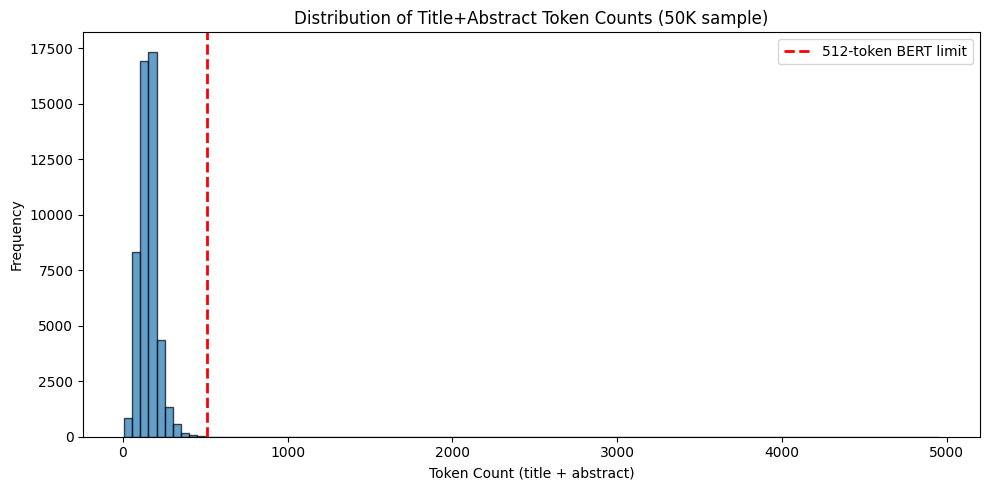

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample["token_count"], bins=100, edgecolor="black", alpha=0.7)
ax.axvline(x=512, color="red", linestyle="--", linewidth=2, label="512-token BERT limit")
ax.set_xlabel("Token Count (title + abstract)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Title+Abstract Token Counts (50K sample)")
ax.legend()
plt.tight_layout()
plt.show()

## Q4: Citation Count Distribution

How many citations does each patent make? What fraction have zero citations (no citation embedding possible)?

In [7]:
# Count citations per patent using only the patent_id column
cn_patent_ids = pq.read_table(citation_path, columns=["patent_id"]).to_pandas()
citation_counts = cn_patent_ids["patent_id"].value_counts()

# Map to all patents (including those with zero citations)
all_patent_ids = pm["patent_id"]
patent_citation_counts = all_patent_ids.map(citation_counts).fillna(0).astype(int)

zero_citations = (patent_citation_counts == 0).sum()

print(f"Citation count per patent:")
print(patent_citation_counts.describe())
print(f"\nZero-citation patents: {zero_citations:,} ({zero_citations/total:.2%})")
print(f"Median citations: {patent_citation_counts.median():.0f}")
print(f"Max citations: {patent_citation_counts.max():,}")
print(f"95th percentile: {patent_citation_counts.quantile(0.95):.0f}")

del cn_patent_ids

Citation count per patent:
count    1.211889e+06
mean     1.377854e+01
std      4.380803e+01
min      0.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.200000e+01
max      4.468000e+03
Name: patent_id, dtype: float64

Zero-citation patents: 92,139 (7.60%)
Median citations: 6
Max citations: 4,468
95th percentile: 45


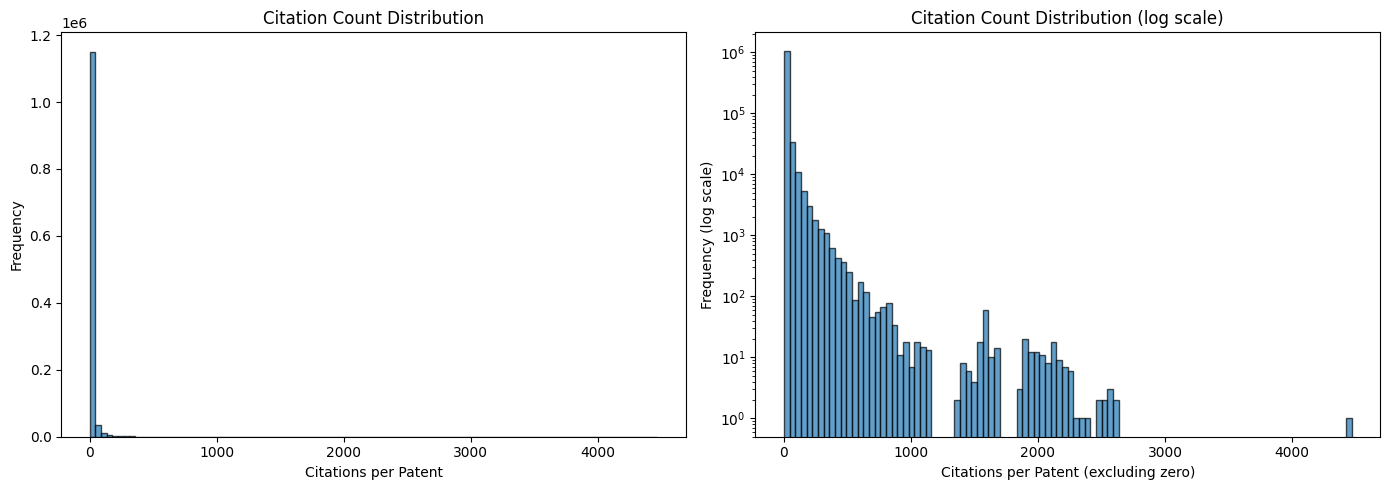

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(patent_citation_counts, bins=100, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Citations per Patent")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Citation Count Distribution")

# Log scale (better for heavy tails)
axes[1].hist(patent_citation_counts[patent_citation_counts > 0], bins=100, edgecolor="black", alpha=0.7)
axes[1].set_yscale("log")
axes[1].set_xlabel("Citations per Patent (excluding zero)")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_title("Citation Count Distribution (log scale)")

plt.tight_layout()
plt.show()

## Q5: Firm Distribution

How many unique firms (gvkeys)? Patent count per firm (min, median, max, p95)?  
This informs downstream GMM fitting — firms with very few patents may need special handling.

In [9]:
# Load gvkey column
gvkeys = pq.read_table(patent_path, columns=["gvkey"]).to_pandas()["gvkey"]
firm_counts = gvkeys.value_counts()

print(f"Unique firms (gvkeys): {len(firm_counts):,}")
print(f"\nPatents per firm:")
print(firm_counts.describe())
print(f"\nMin:    {firm_counts.min()}")
print(f"Median: {firm_counts.median():.0f}")
print(f"P95:    {firm_counts.quantile(0.95):.0f}")
print(f"P99:    {firm_counts.quantile(0.99):.0f}")
print(f"Max:    {firm_counts.max():,}")
print(f"\nFirms with <5 patents:  {(firm_counts < 5).sum():,} ({(firm_counts < 5).mean():.1%})")
print(f"Firms with <10 patents: {(firm_counts < 10).sum():,} ({(firm_counts < 10).mean():.1%})")

Unique firms (gvkeys): 1,892

Patents per firm:
count      1892.000000
mean        640.533298
std        5278.246994
min           1.000000
25%           2.000000
50%           9.000000
75%          54.000000
max      156616.000000
Name: count, dtype: float64

Min:    1
Median: 9
P95:    1188
P99:    15111
Max:    156,616

Firms with <5 patents:  694 (36.7%)
Firms with <10 patents: 962 (50.8%)


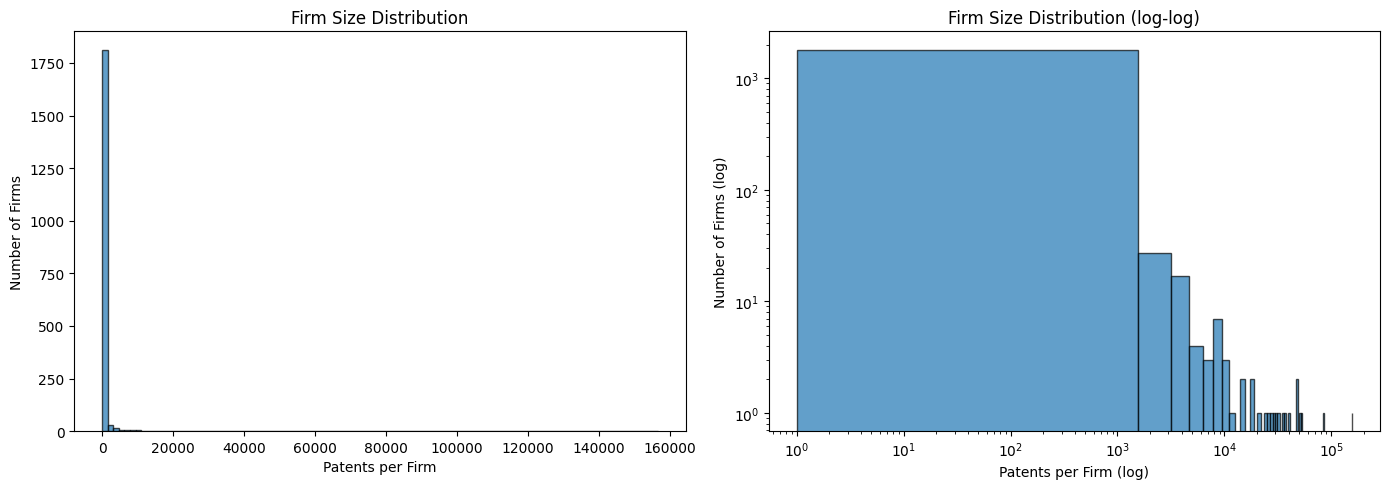

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(firm_counts, bins=100, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Patents per Firm")
axes[0].set_ylabel("Number of Firms")
axes[0].set_title("Firm Size Distribution")

# Log-log for power law check
axes[1].hist(firm_counts, bins=100, edgecolor="black", alpha=0.7)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Patents per Firm (log)")
axes[1].set_ylabel("Number of Firms (log)")
axes[1].set_title("Firm Size Distribution (log-log)")

plt.tight_layout()
plt.show()

## Q6: Citation Coverage

What fraction of `citation_id`s in the citation network have matching abstracts in `cited_abstracts.parquet`?  
Missing citations reduce citation embedding quality and may require imputation or exclusion.

In [11]:
# Load unique citation_ids from network and patent_ids from cited_abstracts
cn_citation_ids = pq.read_table(citation_path, columns=["citation_id"]).to_pandas()["citation_id"]
unique_citation_ids = cn_citation_ids.unique()

cited_patent_ids = pq.read_table(cited_path, columns=["patent_id"]).to_pandas()["patent_id"]
unique_cited_ids = set(cited_patent_ids.unique())

# Coverage: what fraction of citation_ids have an abstract?
has_abstract = sum(1 for cid in unique_citation_ids if cid in unique_cited_ids)
coverage = has_abstract / len(unique_citation_ids)

print(f"Unique citation_ids in network: {len(unique_citation_ids):,}")
print(f"Unique patent_ids in cited_abstracts: {len(unique_cited_ids):,}")
print(f"Citation IDs with matching abstract: {has_abstract:,} ({coverage:.2%})")
print(f"Citation IDs WITHOUT abstract: {len(unique_citation_ids) - has_abstract:,} ({1 - coverage:.2%})")

# Also check: what fraction of citation EDGES have abstracts?
total_edges = len(cn_citation_ids)
edges_with_abstract = cn_citation_ids.isin(unique_cited_ids).sum()
print(f"\nEdge-level coverage: {edges_with_abstract:,}/{total_edges:,} ({edges_with_abstract/total_edges:.2%})")

del cn_citation_ids, cited_patent_ids

Unique citation_ids in network: 2,077,457
Unique patent_ids in cited_abstracts: 1,872,555
Citation IDs with matching abstract: 1,872,555 (90.14%)
Citation IDs WITHOUT abstract: 204,902 (9.86%)



Edge-level coverage: 16,210,166/16,698,056 (97.08%)


## Q7: Duplicate Detection

Any duplicate `patent_id`s in `patent_metadata.parquet`? Duplicates would cause double-counting in firm portfolio construction.

In [12]:
# Check for duplicate patent_ids
patent_ids = pm["patent_id"]
duplicates = patent_ids[patent_ids.duplicated(keep=False)]

print(f"Total patent_ids: {len(patent_ids):,}")
print(f"Unique patent_ids: {patent_ids.nunique():,}")
print(f"Duplicate patent_ids: {patent_ids.duplicated().sum():,}")

if patent_ids.duplicated().sum() > 0:
    print("\nExample duplicates (first 10):")
    dup_ids = patent_ids[patent_ids.duplicated(keep="first")].head(10)
    for pid in dup_ids:
        count = (patent_ids == pid).sum()
        print(f"  patent_id={pid}: appears {count} times")
else:
    print("\nNo duplicates found - patent_id is a valid unique key.")

Total patent_ids: 1,211,889


Unique patent_ids: 1,211,889


Duplicate patent_ids: 0



No duplicates found - patent_id is a valid unique key.


## Q8: Sample Inspection

Print 10 example patents with title and abstract. Do they look like real patents? Any obvious data quality issues?

In [13]:
# Show 10 random patents
rng2 = np.random.RandomState(123)
inspect_idx = rng2.choice(len(pm), size=10, replace=False)
inspect = pm.iloc[inspect_idx][["patent_id", "title", "abstract"]]

for _, row in inspect.iterrows():
    print(f"--- patent_id: {row['patent_id']} ---")
    print(f"Title: {row['title']}")
    abstract = str(row["abstract"])[:300] if pd.notna(row["abstract"]) else "[NULL]"
    print(f"Abstract: {abstract}...\n")

--- patent_id: 7331158 ---
Title: Process and system for product packaging
Abstract: A process and system are provided for printing variable data on packaging material at a package printer and machine reading the variable data on a packaging facility packaging line and associating the variable data with other information in a computer database. The process and system render unnecess...

--- patent_id: 11272080 ---
Title: Vibration device for dust removal and imaging device
Abstract: A vibration device comprises a vibrating member having at least n (n≥2) piezoelectric elements arranged on a vibrating plate, each of the piezoelectric elements being formed by using a lead-free piezoelectric material and electrodes, wherein if the temperature that maximizes the piezoelectric consta...

--- patent_id: 7024427 ---
Title: Virtual file system
Abstract: A virtual file system and method. The system architecture enables a plurality of underlying file systems running on various file servers to be 

## Bonus: Year Distribution

The `patent_metadata` file has `year` and `grant_date` columns not documented in `data_prep.md`.  
Quick check: what years are represented? Is this really a 2020 window or cumulative?

In [14]:
# Check year distribution
years = pq.read_table(patent_path, columns=["year"]).to_pandas()["year"]
print(f"Year range: {years.min()} - {years.max()}")
print(f"\nYear distribution:")
print(years.value_counts().sort_index())

Year range: 1976 - 2023

Year distribution:
year
1976     3493
1977     3559
1978     3461
1979     2430
1980     2768
1981     3397
1982     3321
1983     3418
1984     4033
1985     4377
1986     4827
1987     6146
1988     6095
1989     7491
1990     6906
1991     7709
1992     8704
1993     9540
1994    10695
1995    11013
1996    13902
1997    14792
1998    21552
1999    23224
2000    24415
2001    27044
2002    28304
2003    30380
2004    30969
2005    31041
2006    37838
2007    31755
2008    33574
2009    35699
2010    44194
2011    42513
2012    43701
2013    49365
2014    57105
2015    57304
2016    56196
2017    54450
2018    49747
2019    54758
2020    57528
2021    52452
2022    48153
2023    46551
Name: count, dtype: int64


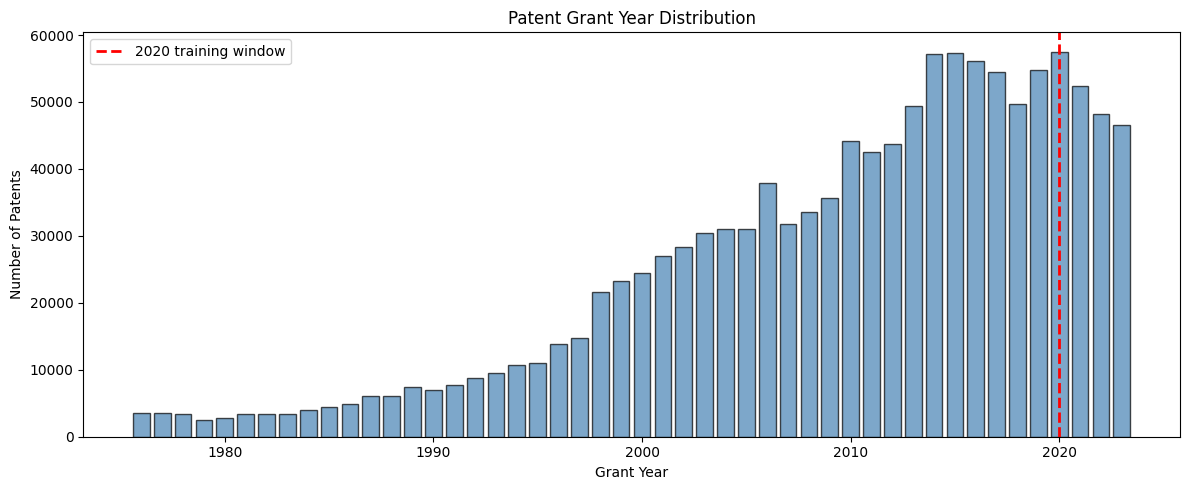

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
year_counts = years.value_counts().sort_index()
ax.bar(year_counts.index, year_counts.values, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(x=2020, color="red", linestyle="--", linewidth=2, label="2020 training window")
ax.set_xlabel("Grant Year")
ax.set_ylabel("Number of Patents")
ax.set_title("Patent Grant Year Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## EDA Summary

| Question | Finding | Implication |
|----------|---------|-------------|
| Q1: Schema | All expected columns present. Extra: `permno`, `year`, `grant_date`, `__index_level_0__` in patent_metadata | `permno`/`year`/`grant_date` may be useful downstream. `__index_level_0__` is a pandas artifact. |
| Q2: Null rates | 0 null titles, 241 null abstracts (0.02%), 0 patents with both missing. 11,229 null cited abstracts (0.60%) | Negligible. Cited nulls contribute nothing to citation mean pooling. |
| Q3: Token lengths | Mean=154, median=152, P95=247, P99=322. Only **0.03% exceed 512 tokens**. | Truncation is a non-issue. Default BERT 512-token limit handles >99.97% of patents. |
| Q4: Citation counts | Mean=13.8, median=6, P95=45, max=4,468. **7.60% have zero citations** (92,139 patents). | Zero-citation handling needed in ADR-002. Zero vector strategy is appropriate. |
| Q5: Firm distribution | 1,892 unique firms. Median=9 patents/firm, max=156,616. **50.8% of firms have <10 patents**. | Downstream GMM will need minimum patent threshold. Highly skewed. |
| Q6: Citation coverage | 90.14% of unique citation_ids have abstracts. **97.08% edge-level coverage**. | Excellent coverage. Mean pooling is robust to the ~10% missing unique citations. |
| Q7: Duplicates | 0 duplicates. patent_id is a valid unique key. | Clean data. |
| Q8: Sample inspection | All 10 samples look like real US patents with proper titles and technical abstracts. | Data quality is good. |
| Bonus: Year dist | Data spans **1976-2023** — cumulative, NOT just 2020. | The 2020 training window refers to the analysis window (which firms), not patent grant years. |

### Key Decisions for Phase 2 ADRs

1. **ADR-001 (Truncation)**: 512-token truncation is effectively a non-issue (0.03%). Default behavior is fine.
2. **ADR-002 (Zero citations)**: 7.6% of patents have zero citations — zero vector strategy is appropriate.
3. **ADR-002 (Coverage)**: 97% edge coverage means mean pooling will be based on nearly complete citation sets.
4. **Firm size skew**: 50.8% of firms have <10 patents — may need minimum threshold for GMM fitting in Week 2.

### Next Step
Present these findings to Torrin for approval, then proceed to Phase 2 (ADRs and Spec).